# BasedData Live Demo

Welcome to the **BasedData Live Demo**! 

### Overview
This Jupyter Notebook consolidates all **M3 test scripts** alongside **custom tests** to showcase the live functionality and performance of the system.

### Features:
- **M3 Test Scripts**: A comprehensive set of tests ensuring the robustness and efficiency of the system.
- **Custom Tests**: Tailored tests designed to highlight specific features and capabilities for the demo.
- **Performance Evaluation**: Graph displaying time taken to concurrently run insert, select, update, and delete for batches of 1, 100, 1000, 10000, and 100000 records.

---

### **M3 Test: Part 1**

---

In [37]:
from lstore.db import Database
from lstore.query import Query
from lstore.transaction import Transaction
from lstore.transaction_worker import TransactionWorker

from random import choice, randint, sample, seed
import time

db = Database()
db.open('./ECS165')

# creating grades table
grades_table = db.create_table('Grades', 5, 0)

# create a query class for the grades table
query = Query(grades_table)

# dictionary for records to test the database: test directory
records = {}

number_of_records = 1000
number_of_transactions = 100
num_threads = 8

# create index on the non primary columns
try:
    grades_table.index.create_index(2)
    grades_table.index.create_index(3)
    grades_table.index.create_index(4)
except Exception as e:
    print('Index API not implemented properly, tests may fail.')

keys = []
records = {}
seed(3562901)

# array of insert transactions
insert_transactions = []

for i in range(number_of_transactions):
    insert_transactions.append(Transaction())

for i in range(0, number_of_records):
    key = 92106429 + i
    keys.append(key)
    records[key] = [key, randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20)]
    t = insert_transactions[i % number_of_transactions]
    t.add_query(query.insert, grades_table, *records[key])

transaction_workers = []
for i in range(num_threads):
    transaction_workers.append(TransactionWorker())
    
for i in range(number_of_transactions):
    transaction_workers[i % num_threads].add_transaction(insert_transactions[i])

insert_start = time.time()

# run transaction workers
for i in range(num_threads):
    transaction_workers[i].run()

# wait for workers to finish
for i in range(num_threads):
    transaction_workers[i].join()

insert_end = time.time()

# Check inserted records using select query in the main thread outside workers
for key in keys:
    record = query.select(key, 0, [1, 1, 1, 1, 1])[0]
    error = False
    for i, column in enumerate(record.columns):
        if column != records[key][i]:
            error = True
    if error:
        print('select error on', key, ':', record, ', correct:', records[key])
    else:
        pass
        # print('select on', key, ':', record)
print("Select finished")
print(f"Concurrent Insertion Took: {insert_end - insert_start} seconds")
print(f"Number of Records: {number_of_records}")
print(f"Number of Transactions: {number_of_transactions}")
print(f"Number of Threads: {num_threads}")

db.close()



Select finished
Concurrent Insertion Took: 0.0846719741821289 seconds
Number of Records: 1000
Number of Transactions: 100
Number of Threads: 8


---

### **M3 Test: Part 2**

---

In [38]:
from lstore.db import Database
from lstore.query import Query
from lstore.transaction import Transaction
from lstore.transaction_worker import TransactionWorker

from random import choice, randint, sample, seed
import time

db = Database()
db.open('./ECS165')

# Getting the existing Grades table
grades_table = db.get_table('Grades')

# create a query class for the grades table
query = Query(grades_table)

# dictionary for records to test the database: test directory
records = {}

number_of_records = 1000
number_of_transactions = 100
number_of_operations_per_record = 10
num_threads = 8

keys = []
records = {}
seed(3562901)

# re-generate records for testing
for i in range(0, number_of_records):
    key = 92106429 + i
    keys.append(key)
    records[key] = [key, randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20)]
    # print(records[key])

transaction_workers = []
transactions = []

for i in range(number_of_transactions):
    transactions.append(Transaction())

for i in range(num_threads):
    transaction_workers.append(TransactionWorker())





# x update on every column
for j in range(number_of_operations_per_record):
    for key in keys:
        updated_columns = [None, None, None, None, None]
        for i in range(2, grades_table.num_columns):
            # updated value
            value = randint(0, 20)
            updated_columns[i] = value
            # copy record to check
            original = records[key].copy()
            # update our test directory
            records[key][i] = value
            transactions[key % number_of_transactions].add_query(query.select, grades_table, key, 0, [1, 1, 1, 1, 1])
            transactions[key % number_of_transactions].add_query(query.update, grades_table, key, *updated_columns)
print("Update finished")


# add trasactions to transaction workers  
for i in range(number_of_transactions):
    transaction_workers[i % num_threads].add_transaction(transactions[i])

update_start = time.time()

# run transaction workers
for i in range(num_threads):
    transaction_workers[i].run()

# wait for workers to finish
for i in range(num_threads):
    transaction_workers[i].join()

update_end = time.time()

score = len(keys)
for key in keys:
    try:
        correct = records[key]
        query = Query(grades_table)
        
        result = query.select(key, 0, [1, 1, 1, 1, 1])[0].columns
        if correct != result:
            print('select error on primary key', key, ':', result, ', correct:', correct)
            score -= 1
    except:
        print('Record Not found', key)
        score -= 1
print('Score', score, '/', len(keys))
print(f"Concurrent Update Took: {update_end - update_start}")
print(f"Number of Records: {number_of_records}")
print(f"Number of Transactions: {number_of_transactions}")
print(f"Number of Operations per Record: {number_of_operations_per_record}")
print(f"Number of Threads: {num_threads}")
db.close()

Update finished
Score 1000 / 1000
Concurrent Update Took: 2.1459991931915283
Number of Records: 1000
Number of Transactions: 100
Number of Operations per Record: 10
Number of Threads: 8


In [104]:
import shutil
shutil.rmtree('./ECS165', ignore_errors=True)

---

### **Exam Tester M3 Part 1**

---

In [40]:
from lstore.db import Database
from lstore.query import Query
from lstore.transaction import Transaction
from lstore.transaction_worker import TransactionWorker

from random import choice, randint, sample, seed
import time

db = Database()
db.open('./ECS165')

# creating grades table
grades_table = db.create_table('Grades', 5, 0)

# create a query class for the grades table
query = Query(grades_table)

# dictionary for records to test the database: test directory
records = {}

number_of_records = 1000
number_of_transactions = 100
num_threads = 8

# create index on the non primary columns
try:
    grades_table.index.create_index(2)
    grades_table.index.create_index(3)
    grades_table.index.create_index(4)
except Exception as e:
    print('Index API not implemented properly, tests may fail.')

keys = []
records = {}
seed(3562901)

# array of insert transactions
insert_transactions = []

for i in range(number_of_transactions):
    insert_transactions.append(Transaction())

for i in range(0, number_of_records):
    key = 92106429 + i
    keys.append(key)
    records[key] = [key, randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20)]
    t = insert_transactions[i % number_of_transactions]
    t.add_query(query.insert, grades_table, *records[key])

transaction_workers = []
for i in range(num_threads):
    transaction_workers.append(TransactionWorker())

for i in range(number_of_transactions):
    transaction_workers[i % num_threads].add_transaction(insert_transactions[i])

insertion_begin = time.time()

# run transaction workers
for i in range(num_threads):
    transaction_workers[i].run()

# wait for workers to finish
for i in range(num_threads):
    transaction_workers[i].join()

insertion_end = time.time()

# Check inserted records using select query in the main thread outside workers
for key in keys:
    record = query.select(key, 0, [1, 1, 1, 1, 1])[0]
    error = False
    for i, column in enumerate(record.columns):
        if column != records[key][i]:
            error = True
    if error:
        print('select error on', key, ':', record, ', correct:', records[key])
print("Select finished")

db.close()
print(f"Concurrent Insertion Took: {insertion_end - insertion_begin} seconds")
print(f"Number of Records: {number_of_records}")
print(f"Number of Transactions: {number_of_transactions}")
print(f"Number of Threads: {num_threads}")

Select finished
Concurrent Insertion Took: 0.06898999214172363 seconds
Number of Records: 1000
Number of Transactions: 100
Number of Threads: 8


---

### **Exam Tester M3 Part 2**

---

In [41]:
from lstore.db import Database
from lstore.query import Query
from lstore.transaction import Transaction
from lstore.transaction_worker import TransactionWorker

from random import choice, randint, sample, seed
import time

db = Database()
db.open('./ECS165')

# Getting the existing Grades table
grades_table = db.get_table('Grades')

# create a query class for the grades table
query = Query(grades_table)

# dictionary for records to test the database: test directory
records = {}

number_of_records = 1000
number_of_transactions = 100
number_of_operations_per_record = 1
num_threads = 8

keys = []
records = {}
seed(3562901)

# re-generate records for testing
for i in range(0, number_of_records):
    key = 92106429 + i
    keys.append(key)
    records[key] = [key, randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20), randint(i * 20, (i + 1) * 20)]
    print(records[key])

transaction_workers = []
transactions = []

for i in range(number_of_transactions):
    transactions.append(Transaction())

for i in range(num_threads):
    transaction_workers.append(TransactionWorker())

updated_records = {}
# x update on every column
for j in range(number_of_operations_per_record):
    for key in keys:
        updated_columns = [None, None, None, None, None]
        updated_records[key] = records[key].copy()
        for i in range(2, grades_table.num_columns):
            value = randint(0, 20)
            updated_columns[i] = value
            updated_records[key][i] = value
        transactions[key % number_of_transactions].add_query(query.select, grades_table, key, 0, [1, 1, 1, 1, 1])
        transactions[key % number_of_transactions].add_query(query.update, grades_table, key, *updated_columns)
print("Update finished")

# add transactions to transaction workers
for i in range(number_of_transactions):
    transaction_workers[i % num_threads].add_transaction(transactions[i])

update_start = time.time()

# run transaction workers
for i in range(num_threads):
    transaction_workers[i].run()

# wait for workers to finish
for i in range(num_threads):
    transaction_workers[i].join()

update_end = time.time()

db.close()
print(f"Concurrent Update Took: {update_end- update_start} seconds")
print(f"Number of Records: {number_of_records}")
print(f"Number of Transactions: {number_of_transactions}")
print(f"Number of Threads: {num_threads}")

[92106429, 9, 1, 14, 1]
[92106430, 39, 26, 33, 22]
[92106431, 50, 50, 48, 42]
[92106432, 64, 61, 78, 80]
[92106433, 80, 94, 95, 90]
[92106434, 120, 107, 110, 106]
[92106435, 130, 139, 127, 135]
[92106436, 144, 145, 145, 143]
[92106437, 179, 168, 175, 166]
[92106438, 190, 183, 188, 181]
[92106439, 206, 217, 217, 218]
[92106440, 239, 221, 225, 229]
[92106441, 247, 256, 252, 249]
[92106442, 266, 276, 280, 265]
[92106443, 295, 293, 290, 281]
[92106444, 319, 315, 310, 302]
[92106445, 329, 339, 320, 333]
[92106446, 359, 343, 343, 353]
[92106447, 374, 362, 365, 375]
[92106448, 392, 398, 393, 386]
[92106449, 408, 411, 401, 402]
[92106450, 421, 433, 440, 435]
[92106451, 453, 460, 460, 449]
[92106452, 461, 476, 463, 464]
[92106453, 481, 489, 499, 487]
[92106454, 518, 517, 512, 509]
[92106455, 530, 521, 533, 534]
[92106456, 548, 546, 556, 560]
[92106457, 563, 569, 571, 563]
[92106458, 581, 580, 600, 594]
[92106459, 611, 609, 619, 619]
[92106460, 634, 628, 638, 624]
[92106461, 652, 641, 647, 649]


In [102]:
shutil.rmtree('./ECS165', ignore_errors=True)

Custom Test

Running test for 1 records...
Running test for 100 records...
Running test for 1000 records...
Running test for 10000 records...
Running test for 100000 records...


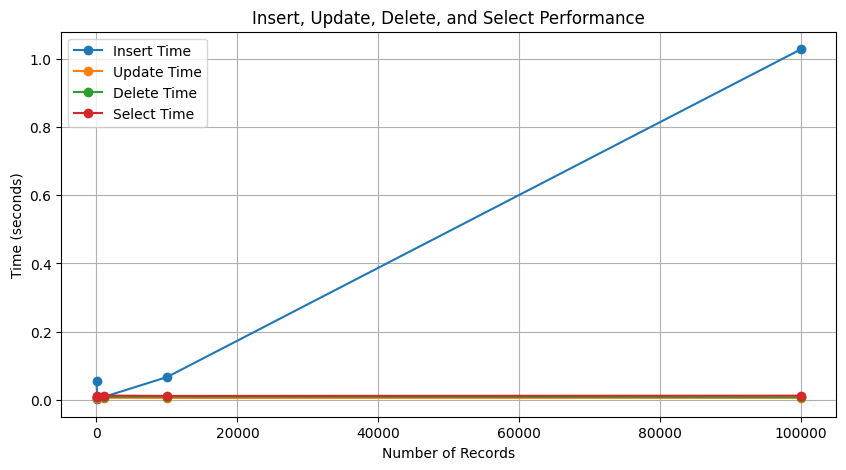

In [103]:
import matplotlib.pyplot as plt
import time
from lstore.db import Database
from lstore.query import Query
from lstore.transaction import Transaction
from lstore.transaction_worker import TransactionWorker
from random import randint, seed

# Initialize database
db = Database()
db.open('./ECS165')

# Creating the grades table
grades_table = db.create_table('Grades', 5, 0)
query = Query(grades_table)

# Different record sizes to test
record_sizes = [1, 100, 1000, 10000, 100000]
insert_times = []
update_times = []
delete_times = []
select_times = []

seed(3562901)

for num_records in record_sizes:
    records = {}
    transactions = []
    transaction_workers = []
    num_threads = 8
    num_transactions = 100

    print(f"Running test for {num_records} records...")

    # Concurrent Insert Test
    insert_start = time.time()
    insert_workers = [TransactionWorker() for _ in range(num_threads)]
    
    for i in range(num_records):
        key = 92106429 + i
        records[key] = [key, randint(0, 100), randint(0, 100), randint(0, 100), randint(0, 100)]
        
        # Create a transaction for inserting and assign it to a worker
        transaction = Transaction()
        transaction.add_query(query.insert, *records[key])
        insert_workers[i % num_threads].add_transaction(transaction)
    
    # Execute transactions using workers
    for worker in insert_workers:
        worker.run()

    for worker in insert_workers:
        worker.join()
    
    insert_end = time.time()
    insert_times.append(insert_end - insert_start)

    # Concurrent Update Test
    update_start = time.time()
    update_workers = [TransactionWorker() for _ in range(num_threads)]
    
    for i in range(num_transactions):
        transaction = Transaction()
        for j in range(10):  # Each transaction updates 10 records
            key = 92106429 + randint(0, num_records - 1)
            new_values = [None, randint(0, 100), None, randint(0, 100), None]
            transaction.add_query(query.update, grades_table, key, *new_values)
        transactions.append(transaction)

    # Distribute updates across workers
    for i, transaction in enumerate(transactions):
        update_workers[i % num_threads].add_transaction(transaction)

    for worker in update_workers:
        worker.run()

    for worker in update_workers:
        worker.join()

    update_end = time.time()
    update_times.append(update_end - update_start)

    # Concurrent Delete Test
    delete_start = time.time()
    delete_workers = [TransactionWorker() for _ in range(num_threads)]
    
    for i in range(num_transactions):
        transaction = Transaction()
        for j in range(10):  # Each transaction deletes 10 records
            key = 92106429 + randint(0, num_records - 1)
            transaction.add_query(query.delete, grades_table, key)
        transactions.append(transaction)

    # Distribute deletes across workers
    for i, transaction in enumerate(transactions):
        delete_workers[i % num_threads].add_transaction(transaction)

    for worker in delete_workers:
        worker.run()

    for worker in delete_workers:
        worker.join()

    delete_end = time.time()
    delete_times.append(delete_end - delete_start)

    # Concurrent Select Test
    select_start = time.time()
    select_workers = [TransactionWorker() for _ in range(num_threads)]
    
    for i in range(num_transactions):
        transaction = Transaction()
        for j in range(10):  # Each transaction selects 10 records
            key = 92106429 + randint(0, num_records - 1)
            transaction.add_query(query.select, grades_table, key)
        transactions.append(transaction)

    # Distribute selects across workers
    for i, transaction in enumerate(transactions):
        select_workers[i % num_threads].add_transaction(transaction)

    for worker in select_workers:
        worker.run()

    for worker in select_workers:
        worker.join()

    select_end = time.time()
    select_times.append(select_end - select_start)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(record_sizes, insert_times, label="Insert Time", marker="o")
plt.plot(record_sizes, update_times, label="Update Time", marker="o")
plt.plot(record_sizes, delete_times, label="Delete Time", marker="o")
plt.plot(record_sizes, select_times, label="Select Time", marker="o")
plt.xlabel("Number of Records")
plt.ylabel("Time (seconds)")
plt.title("Insert, Update, Delete, and Select Performance")
plt.legend()
plt.grid(True)
plt.show()